In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)

print("Loading data...")

train_df = pd.read_csv('/content/train.csv')
test_df = pd.read_csv('/content/test.csv')

X = train_df.iloc[:, 1:].values
y = train_df.iloc[:, 0].values

X = X / 255.0
test_X = test_df.values / 255.0

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.1, random_state=SEED
)
input_size = 784
num_classes = 10
learning_rate = 0.1
epochs = 50

W = np.random.randn(input_size, num_classes) * 0.01
b = np.zeros((1, num_classes))
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)
def one_hot(y, num_classes):
    onehot = np.zeros((len(y), num_classes))
    onehot[np.arange(len(y)), y] = 1
    return onehot
def accuracy(preds, labels):
    return np.mean(preds == labels)
print("Starting training...")

y_train_onehot = one_hot(y_train, num_classes)
y_val_onehot = one_hot(y_val, num_classes)

for epoch in range(epochs):

    # Forward pass
    logits = np.dot(X_train, W) + b
    probs = softmax(logits)

    # Loss (Cross Entropy)
    loss = -np.mean(np.sum(y_train_onehot * np.log(probs + 1e-8), axis=1))

    # Backward pass
    grad_logits = probs - y_train_onehot
    dW = np.dot(X_train.T, grad_logits) / X_train.shape[0]
    db = np.sum(grad_logits, axis=0, keepdims=True) / X_train.shape[0]

    # Update
    W -= learning_rate * dW
    b -= learning_rate * db

    # Validation
    val_logits = np.dot(X_val, W) + b
    val_preds = np.argmax(val_logits, axis=1)
    val_acc = accuracy(val_preds, y_val)

    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Loss: {loss:.4f} | Val Acc: {val_acc:.4f}")
print("Generating predictions...")

test_logits = np.dot(test_X, W) + b
test_preds = np.argmax(test_logits, axis=1)

submission = pd.DataFrame({
    "ImageId": range(1, len(test_preds) + 1),
    "Label": test_preds
})

submission.to_csv("submission.csv", index=False)
print("submission.csv saved!")


Loading data...
Starting training...
Epoch 5/50 | Loss: 1.9469 | Val Acc: 0.7310
Epoch 10/50 | Loss: 1.6099 | Val Acc: 0.7740
Epoch 15/50 | Loss: 1.3781 | Val Acc: 0.7940
Epoch 20/50 | Loss: 1.2153 | Val Acc: 0.8079
Epoch 25/50 | Loss: 1.0970 | Val Acc: 0.8171
Epoch 30/50 | Loss: 1.0078 | Val Acc: 0.8248
Epoch 35/50 | Loss: 0.9385 | Val Acc: 0.8295
Epoch 40/50 | Loss: 0.8830 | Val Acc: 0.8340
Epoch 45/50 | Loss: 0.8376 | Val Acc: 0.8390
Epoch 50/50 | Loss: 0.7997 | Val Acc: 0.8421
Generating predictions...
submission.csv saved!


kaggle submission:
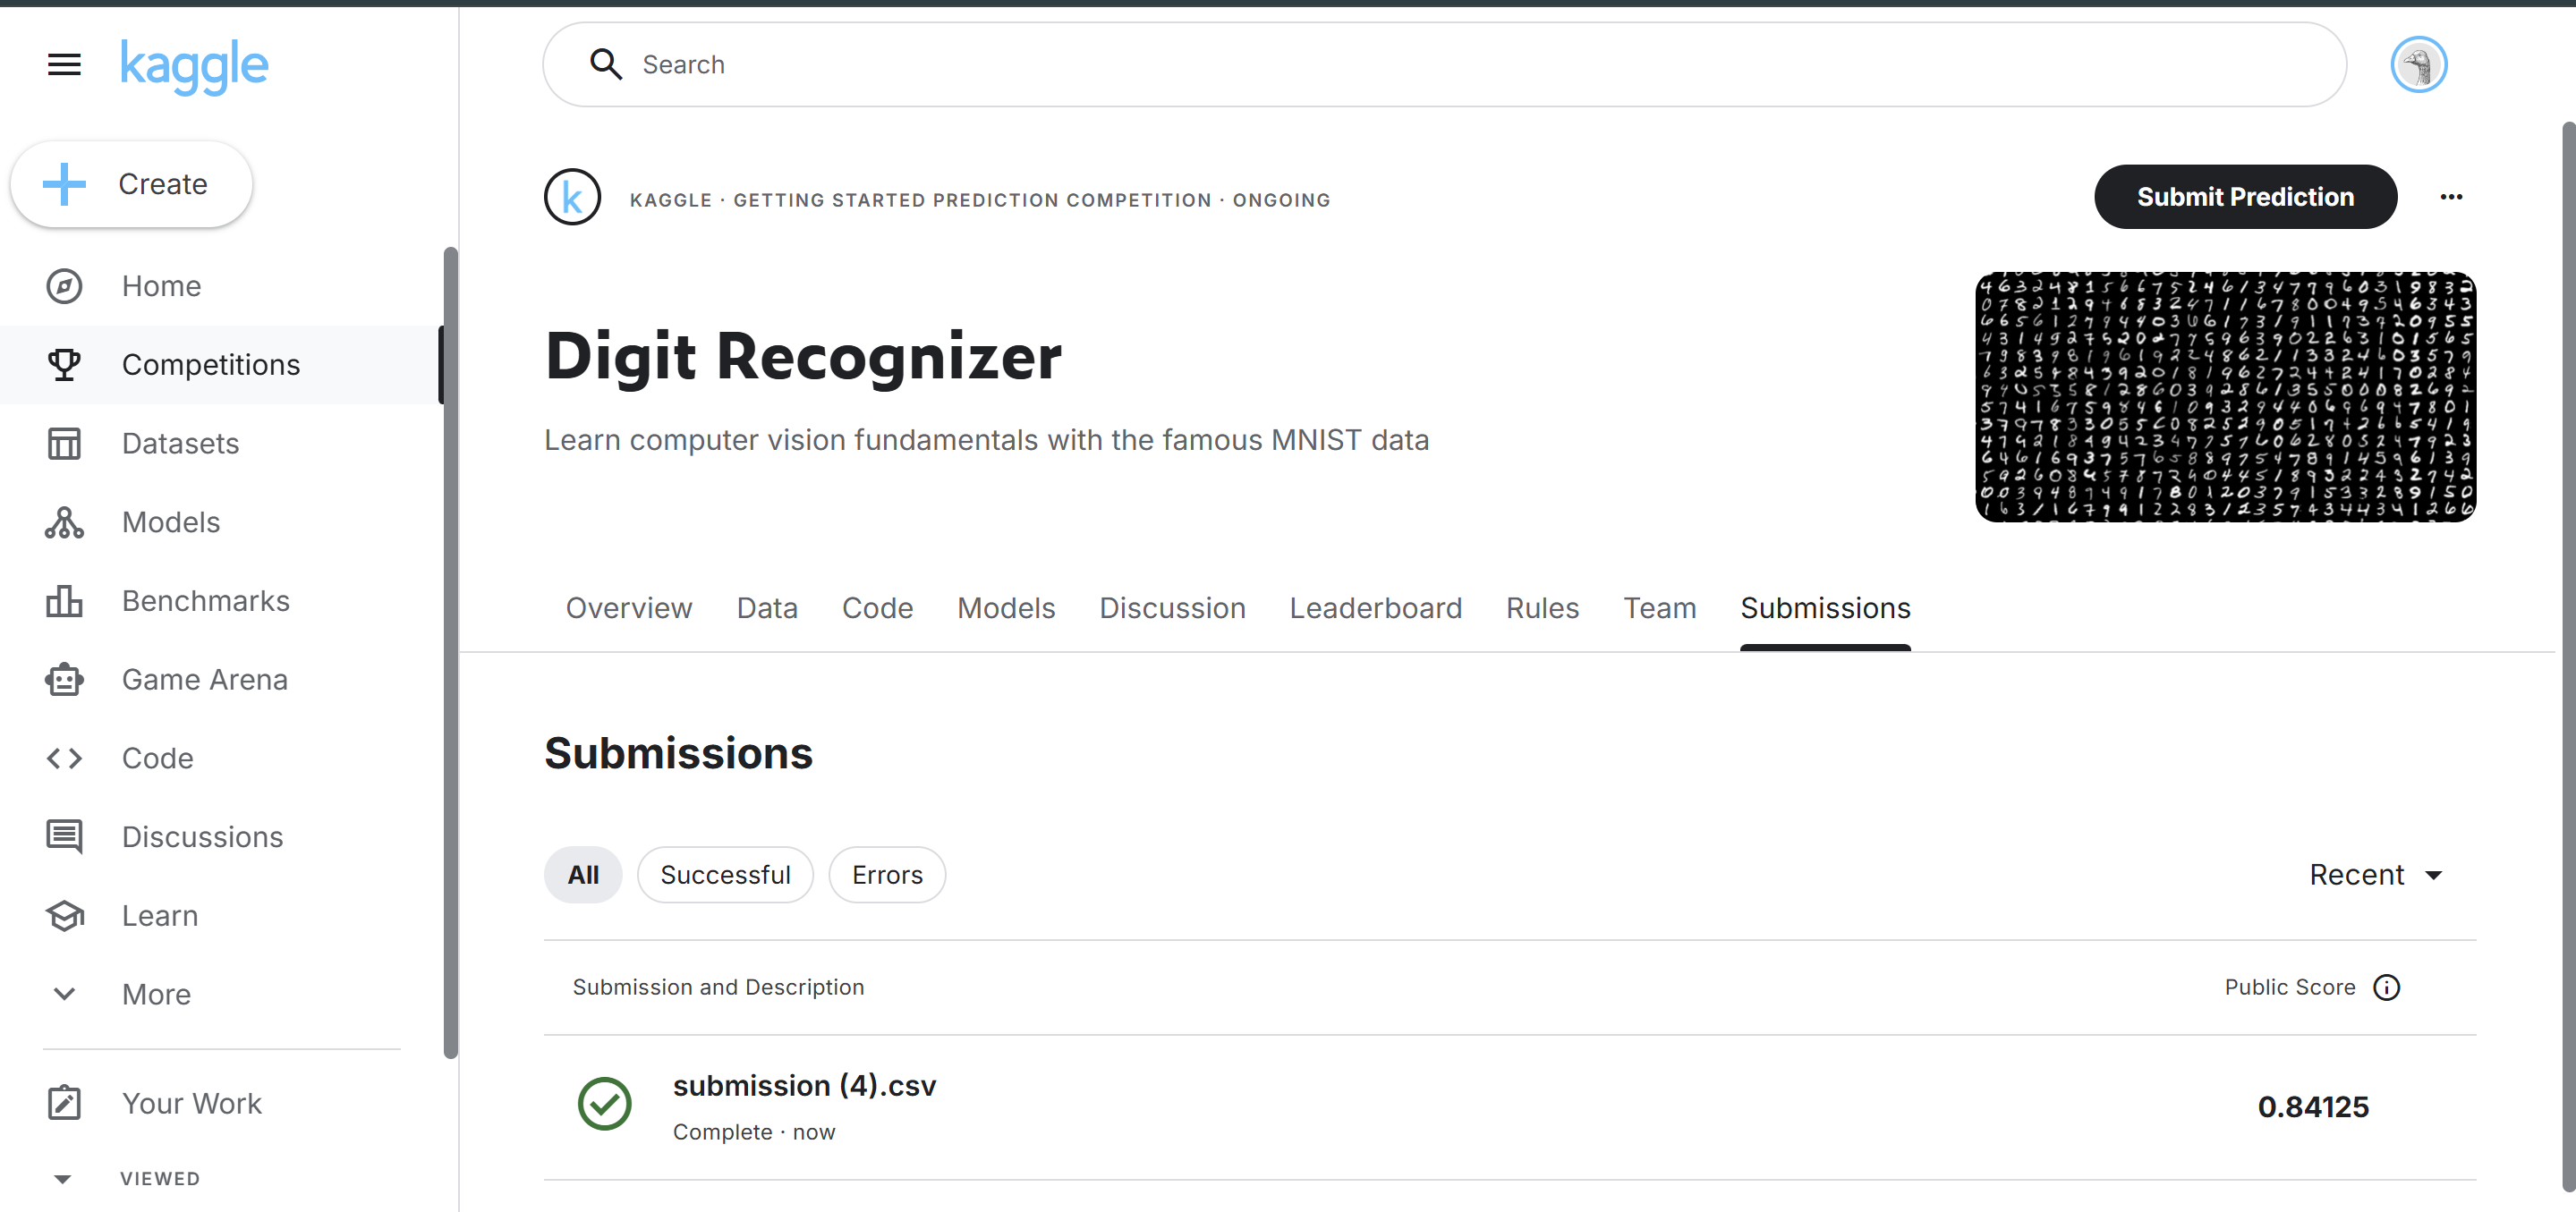